## Supervised learning example: regression.

## Prediction of photovoltaic generation for self-consumption.

**Objective:** To predict the next day's PV generation of a household, in order to intelligently manage its consumption. We will use historical data of the target variable we want to predict (historical PV generation data) and other features that can help to predict the model, such as irradiance or temperature.



### Before you start:

* In the file **S5_examplePV1.csv** is the input data set for this example (attributes + tag). 

## **1. Import libraries and data**.

In [ ]:
# We import libraries
import sklearn
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

# We load the input data set
dataset = pd.read_csv('Data/EJ1-data-pv.csv', delimiter=';')

## **2. Understanding the data**

It is necessary to visualize and understand the data we are going to work with, as well as to know its characteristics. 

1. How many rows we have? How many attributes are there in the data?  
2. What are these attributes?
3. Is there any missing data?
4. Statistical summary of the input data set.

**How many attributes are there in the data?**

In [78]:
### Dataset shape
dataset.shape

(25034, 8)

**What do they mean?**

In [79]:
# First 5 rows
dataset.head()

,localhour,pressure,temperature,humidity,windspeed,rain,radiation,pvgen
0,19/02/2015 12:00,1024.4,17.0,56.0,4.0,0.0,672.0,6.646
1,19/02/2015 13:00,NaN,18.0,47.0,4.0,0.0,NaN,7.364
2,19/02/2015 14:00,1021.4,19.0,47.0,4.0,0.0,781.0,7.418
3,19/02/2015 15:00,1019.9,20.0,41.0,4.0,0.0,664.0,6.616
4,19/02/2015 16:00,1018.6,21.0,42.0,4.0,0.0,505.0,4.795


In [80]:
# data format
dataset.dtypes

localhour       object
pressure       float64
temperature    float64
humidity       float64
windspeed      float64
rain           float64
radiation      float64
pvgen          float64
dtype: object

In [81]:
# Convert localhour in datetime
dataset['localhour'] = pd.to_datetime(dataset['localhour'])

C:\Users\sarab\AppData\Local\Temp\ipykernel_24436\3250755085.py:2: UserWarning:

Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [82]:
dataset['localhour']

0       2015-02-19 12:00:00
1       2015-02-19 13:00:00
2       2015-02-19 14:00:00
3       2015-02-19 15:00:00
4       2015-02-19 16:00:00
                ...        
25029   2018-05-01 19:00:00
25030   2018-05-01 20:00:00
25031   2018-05-01 21:00:00
25032   2018-05-01 22:00:00
25033   2018-05-01 23:00:00
Name: localhour, Length: 25034, dtype: datetime64[ns]

**3. Is any data missing?** A check is made to see if any data is missing, and if so, the count of empty cells in each attribute is performed. In this case, no data is missing.

In [83]:
# Check for missing data
dataset.isna().sum()

localhour      0
pressure       4
temperature    1
humidity       3
windspeed      1
rain           0
radiation      3
pvgen          0
dtype: int64

**4. Statistical Summary of the data.**

In [84]:
dataset.describe()

,localhour,pressure,temperature,humidity,windspeed,rain,radiation,pvgen
count,25034,25030.000000,25033.000000,25031.000000,25033.000000,25034.000000,25031.000000,25034.000000
mean,2016-09-21 06:14:40.370695936,1015.932185,21.415412,70.595621,1.432589,0.029356,177.602293,1.493409
min,2015-02-19 12:00:00,997.000000,-6.000000,11.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-01-10 18:15:00,1011.800000,17.000000,56.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-09-27 13:30:00,1015.100000,22.000000,74.000000,1.000000,0.000000,3.000000,0.010000
75%,2017-06-15 13:45:00,1019.500000,27.000000,88.000000,2.000000,0.000000,291.000000,2.550750
max,2018-05-01 23:00:00,1045.500000,40.000000,98.000000,9.000000,32.800000,1101.000000,9.538000
std,NaN,6.258444,7.595223,19.502255,1.247985,0.462885,267.362527,2.241482


## Visualize the data.

A visual way to understand the input data. 

1. Boxplots and Density plots
2. Correlation matrix

### 3.1 Boxplots

The boxplot allows us to identify outliers and compare distributions. In addition, we know how 50% of the values are distributed (inside the box).

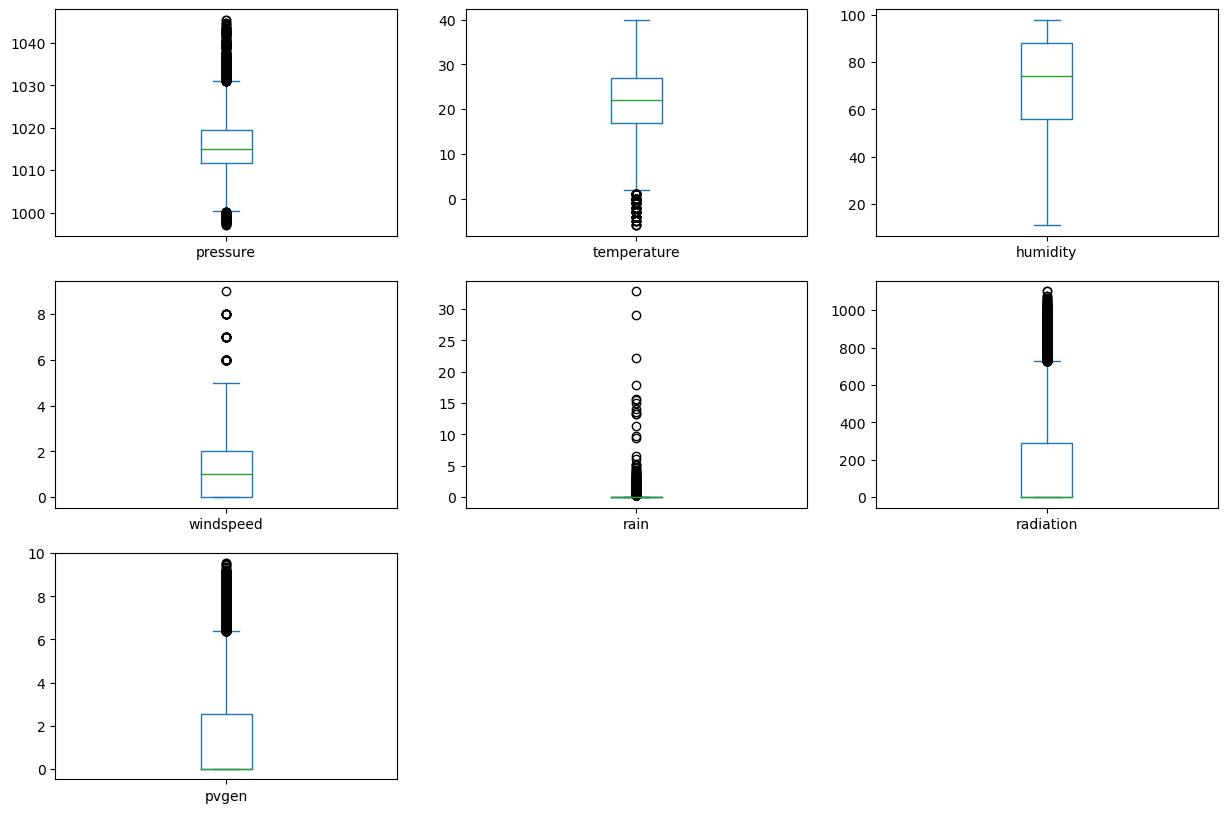

In [85]:
atributos_boxplot = dataset.plot(kind='box', subplots=True, layout=(3, 3), figsize=(15, 10), sharex=False,
                                 sharey=False, fontsize=10)
plt.show()

Add density plots

### **Correlation matrix** 

**3.2. Double-entry table of attributes**

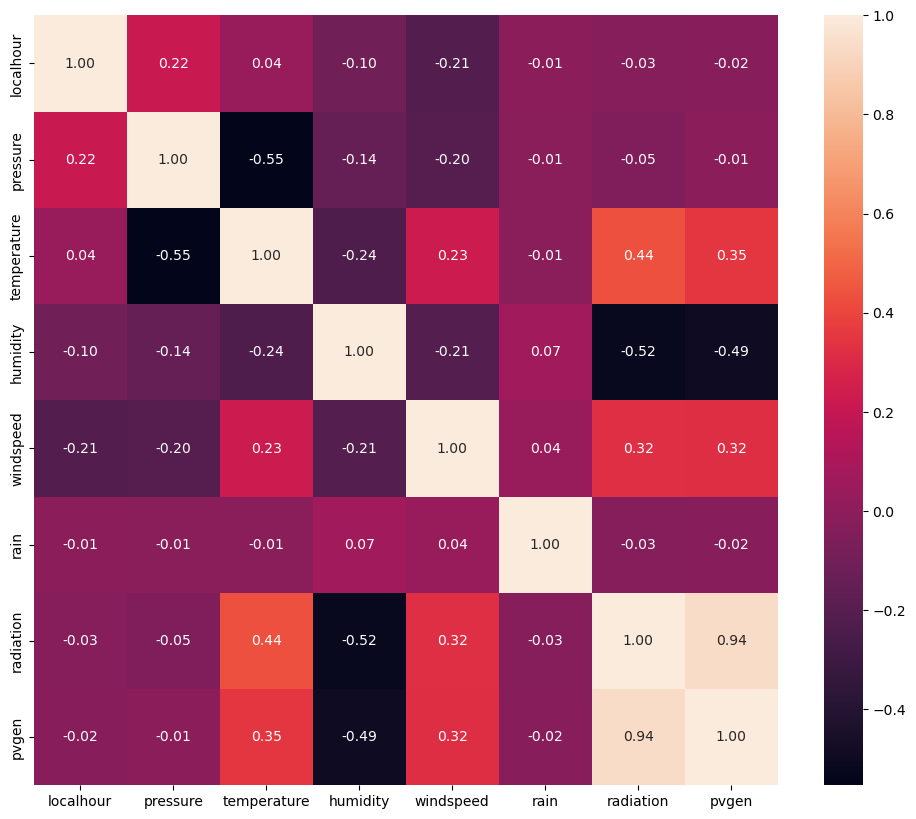

In [86]:
### Seaborn visualization library
import seaborn as sns

# Calculation of correlation coefficients
#Pearson for linear correlation
#Spearman for montonous correlation
#https://duchesnay.github.io/pystatsml/auto_gallery/ml_resampling.html
    
corr = dataset.corr(method='pearson') 
# Remove repeated values
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
  
f, ax = plt.subplots(figsize=(12, 10))
#Generar Heat Map,
sns.heatmap(corr, annot=True, fmt=".2f")
    # xticks
#plt.xticks(range(len(corr.columns)), corr.columns);
    # yticks
#plt.yticks(range(len(corr.columns)), corr.columns)
    # plot
plt.show()

## *4. Prepare the data*.




Add ``time`` and ``month`` columns through the datetime column. 
The data is scaled

In [87]:
# Add month and time columns
dataset['month'] = pd.DatetimeIndex(dataset['localhour']).month
dataset['hour'] = pd.DatetimeIndex(dataset['localhour']).hour
dataset.drop(['localhour'], axis=1, inplace=True)
dataset

,pressure,temperature,humidity,windspeed,rain,radiation,pvgen,month,hour
0,1024.4,17.0,56.0,4.0,0.0,672.0,6.646,2,12
1,NaN,18.0,47.0,4.0,0.0,NaN,7.364,2,13
2,1021.4,19.0,47.0,4.0,0.0,781.0,7.418,2,14
3,1019.9,20.0,41.0,4.0,0.0,664.0,6.616,2,15
4,1018.6,21.0,42.0,4.0,0.0,505.0,4.795,2,16
...,...,...,...,...,...,...,...,...,...
25029,1013.6,25.0,85.0,0.0,0.0,125.0,0.060,5,19
25030,1014.0,24.0,84.0,0.0,0.0,2.0,0.000,5,20
25031,1014.6,24.0,85.0,0.0,0.0,0.0,0.000,5,21
25032,1015.3,24.0,86.0,0.0,0.0,0.0,0.000,5,22


Divide the data into **attributes**: X (features) and **tags**: y (target).

In [88]:
# Features X ; Target y 
X = dataset.drop(['pvgen'], axis=1) 
y = dataset['pvgen']

In [89]:
X

,pressure,temperature,humidity,windspeed,rain,radiation,month,hour
0,1024.4,17.0,56.0,4.0,0.0,672.0,2,12
1,NaN,18.0,47.0,4.0,0.0,NaN,2,13
2,1021.4,19.0,47.0,4.0,0.0,781.0,2,14
3,1019.9,20.0,41.0,4.0,0.0,664.0,2,15
4,1018.6,21.0,42.0,4.0,0.0,505.0,2,16
...,...,...,...,...,...,...,...,...
25029,1013.6,25.0,85.0,0.0,0.0,125.0,5,19
25030,1014.0,24.0,84.0,0.0,0.0,2.0,5,20
25031,1014.6,24.0,85.0,0.0,0.0,0.0,5,21
25032,1015.3,24.0,86.0,0.0,0.0,0.0,5,22


In [90]:
y

0        6.646
1        7.364
2        7.418
3        6.616
4        4.795
         ...  
25029    0.060
25030    0.000
25031    0.000
25032    0.000
25033    0.000
Name: pvgen, Length: 25034, dtype: float64

### Impute missing data

First, let's check if there is missing data we should handle

In [91]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
pressure       4
temperature    1
humidity       3
windspeed      1
rain           0
radiation      3
month          0
hour           0
dtype: int64

Missing values in y:
0


## *5. Split the data*.

The data are divided into training data ``X_train``, ``y_train``, validation data ``X_val``, ``y_val`` and test data ``X_test``, ``y_test``.


In [92]:
from sklearn.model_selection import train_test_split

test_size = 0.2  # percentage of the input data that I will use to validate the model
  
# I divide the data into training, validation and test data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                    shuffle=False)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size,
                                                    shuffle=False)

In [93]:
X_train

,pressure,temperature,humidity,windspeed,rain,radiation,month,hour
0,1024.4,17.0,56.0,4.0,0.0,672.0,2,12
1,NaN,18.0,47.0,4.0,0.0,NaN,2,13
2,1021.4,19.0,47.0,4.0,0.0,781.0,2,14
3,1019.9,20.0,41.0,4.0,0.0,664.0,2,15
4,1018.6,21.0,42.0,4.0,0.0,505.0,2,16
...,...,...,...,...,...,...,...,...
16016,1016.4,15.0,96.0,0.0,0.3,18.0,2,9
16017,1017.0,16.0,94.0,1.0,0.0,68.0,2,10
16018,1017.4,16.0,92.0,1.0,0.0,108.0,2,11
16019,1017.2,17.0,87.0,1.0,0.0,191.0,2,12


In [94]:
y_test

20027    2.845
20028    0.847
20029    0.000
20030    0.000
20031    0.000
         ...  
25029    0.060
25030    0.000
25031    0.000
25032    0.000
25033    0.000
Name: pvgen, Length: 5007, dtype: float64

In [95]:
X_test

,pressure,temperature,humidity,windspeed,rain,radiation,month,hour
20027,1008.8,37.0,41.0,3.0,0.0,464.0,8,18
20028,1008.5,37.0,44.0,3.0,0.0,303.0,8,19
20029,1008.9,35.0,51.0,3.0,0.0,28.0,8,20
20030,1009.3,33.0,64.0,3.0,0.0,0.0,8,21
20031,1011.4,32.0,68.0,2.0,0.0,0.0,8,22
...,...,...,...,...,...,...,...,...
25029,1013.6,25.0,85.0,0.0,0.0,125.0,5,19
25030,1014.0,24.0,84.0,0.0,0.0,2.0,5,20
25031,1014.6,24.0,85.0,0.0,0.0,0.0,5,21
25032,1015.3,24.0,86.0,0.0,0.0,0.0,5,22


#### Where is the missing data?



In [96]:
print("Missing values in X train, X val and X test:")
print(X_train.isnull().sum())
print(X_val.isnull().sum())
print(X_test.isnull().sum())



Missing values in X train, X val and X test:
pressure       2
temperature    0
humidity       1
windspeed      1
rain           0
radiation      3
month          0
hour           0
dtype: int64
pressure       0
temperature    0
humidity       1
windspeed      0
rain           0
radiation      0
month          0
hour           0
dtype: int64
pressure       2
temperature    1
humidity       1
windspeed      0
rain           0
radiation      0
month          0
hour           0
dtype: int64


### Impute missing data

####  **Don't impute before splitting!**

If you impute before splitting into train/test, you will be using information from the test set (its statistics like mean/median) to fill missing values in the training data. 

That's called **data leakage** — it contaminates your training process and gives over-optimistic results.

* Correct approach:

    * Split the data → training & testing.
    * Fit the imputer only on the training data.
    * Apply (transform) it to both the training and test sets.
    
    
PS: If you use some other imputation methods, like backfll/interpolation/etc. then there is no data leakage. 

In [97]:

# Interpolate on training data
X_train_interpolated = X_train.interpolate(method='linear')

# Apply interpolation to val and test set
X_val_interpolated = X_val.interpolate(method='linear')
X_test_interpolated = X_test.interpolate(method='linear')

In [98]:
print("Missing values in X train, X val and X test:")
print(X_train_interpolated.isnull().sum())
print(X_val_interpolated.isnull().sum())
print(X_test_interpolated.isnull().sum())

Missing values in X train, X val and X test:
pressure       0
temperature    0
humidity       0
windspeed      0
rain           0
radiation      0
month          0
hour           0
dtype: int64
pressure       0
temperature    0
humidity       0
windspeed      0
rain           0
radiation      0
month          0
hour           0
dtype: int64
pressure       0
temperature    0
humidity       0
windspeed      0
rain           0
radiation      0
month          0
hour           0
dtype: int64


### Scale the data

The **data is scaled** using the ``MinMaxScaler()`` method, which scales and translates each attribute individually such that it is within the range [0, 1]. This needs to be done when the scales of the attributes are different (e.g. radiation [0, 650], wind speed [2, 15]).

In [99]:
from sklearn.preprocessing import MinMaxScaler

# scale attributes/features
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_interpolated),
    columns=X_train_interpolated.columns)
X_train_scaled.head()

,pressure,temperature,humidity,windspeed,rain,radiation,month,hour
0,0.564948,0.511111,0.505882,0.444444,0.0,0.610354,0.090909,0.521739
1,0.534021,0.533333,0.400000,0.444444,0.0,0.659855,0.090909,0.565217
2,0.503093,0.555556,0.400000,0.444444,0.0,0.709355,0.090909,0.608696
3,0.472165,0.577778,0.329412,0.444444,0.0,0.603088,0.090909,0.652174
4,0.445361,0.600000,0.341176,0.444444,0.0,0.458674,0.090909,0.695652


#### Apply the scaler to X_val and X_test

In [100]:
# Transform validation and test data using the same scaler

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val_interpolated),
    columns=X_val_interpolated.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_interpolated),
    columns=X_test_interpolated.columns
)

## *6. Model building and evaluation*.

* The selected evaluation metrics are **RMSE and R2**.
* Check all the available evaluation metrics in Scikit Learn https://scikit-learn.org/stable/modules/model_evaluation.html
![available evaluation metrics](./Figures/regression_evaluationmetric.png)

In [103]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

# number of folds for cross-validation

num_folds =3  # To make the code run faster in class, I have reduced the number of folds. But this number should be somewhat higher. 

error_metrics = {'neg_mean_squared_error', 'r2'}
models = {('MLP', MLPRegressor()),('RFR', RandomForestRegressor()),
          ('SVR', SVR()), ('AdaB', AdaBoostRegressor())}



Each of the models is trained, the results are saved and compared visually.

Evaluation metric:  r2
Model  MLP


C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Model  AdaB
Model  RFR
Model  SVR
[('MLP', 0.874757561449582, 0.050232052585923455), ('AdaB', 0.8225374272179433, 0.039083878057593995), ('RFR', 0.8876768023260064, 0.035189719551079905), ('SVR', 0.8694358574192759, 0.060196483009013264)]


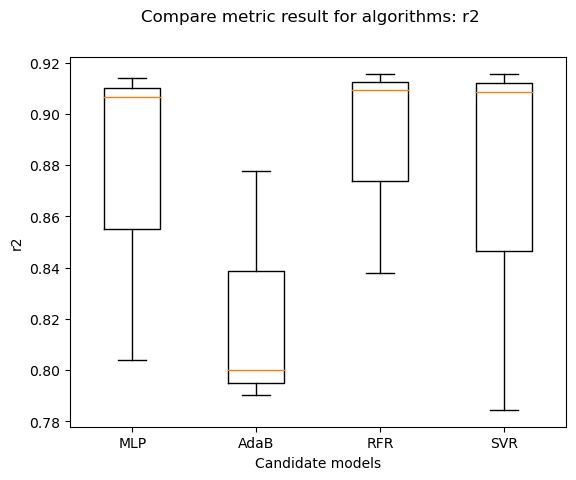

Evaluation metric:  neg_mean_squared_error
Model  MLP


C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

C:\Users\sarab\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



Model  AdaB
Model  RFR
Model  SVR
[('MLP', -0.6754310500228972, 0.3091723793574168), ('AdaB', -1.060016855578364, 0.49863442416717535), ('RFR', -0.6524372006264171, 0.30993477518327767), ('SVR', -0.7679252163520274, 0.4622604315549094)]


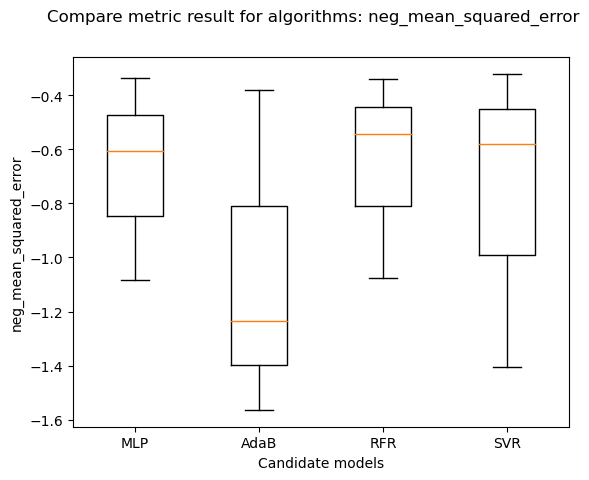

In [104]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV

# Cross-validation training
for scoring in error_metrics:
    results = [] # store metrics results
    msg = []  # print summary of result
    names = []  # store name of the models
    print('Evaluation metric: ', scoring)
    for name, model in models:
        print('Model ', name)
        cross_validation = TimeSeriesSplit(n_splits=num_folds)
        cv_results = cross_val_score(model, X_train_scaled, y_train, cv=cross_validation, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        resume = (name, cv_results.mean(), cv_results.std())
        msg.append(resume)
    print(msg)

    # Compare results between algorithms
    fig = plt.figure()
    fig.suptitle('Compare metric result for algorithms: %s' %scoring)
    ax = fig.add_subplot(111)
    ax.set_xlabel('Candidate models')
    ax.set_ylabel('%s' %scoring)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

    results = []


In [ ]:
msg

## *7. Adjust hyperparameters*.

Steps to perform the hyperadjustment of the parameters:
* Specify the model to be adjusted
* Specify a metric to optimize
* Define the search parameter ranges: *params*
* Assign a validation method: *KFold*
* Find the Hyperparameters with the validation data: *X_val*


**To make the code run faster in class, we have only used two possible values for the ``n_estimators`` hyperparameter. In reality, the more hyperparameters you test, the better. And the more values per hyperparameter, too. But this can be computationally very intensive. Find a good trade-off.**

In [105]:
modelo = RandomForestRegressor()
scoring='r2'


params = {
    # Number of trees in random forest
    'n_estimators': [10, 200],  # default=100
     # Maximum number of levels in tree
    # 'max_depth': [2, None],  #deafult = None
     # Method of selecting samples for training each tree
}


# Search for the best combination of hyperparameters
cross_validation = TimeSeriesSplit(n_splits=5)
my_cv = cross_validation.split(X_val_scaled)
gsearch = GridSearchCV(estimator=modelo, param_grid=params, scoring=scoring, cv=my_cv)
gsearch.fit(X_val_scaled, y_val)

# Print best Result
print("Best result: %f using the following hyperparameters %s" % (gsearch.best_score_, gsearch.best_params_))
means = gsearch.cv_results_['mean_test_score']
stds = gsearch.cv_results_['std_test_score']
params = gsearch.cv_results_['params']

Best result: 0.926083 using the following hyperparameters {'n_estimators': 200}


## *8. Final evaluation of the model*.


Finally, PV generation predictions are made.

Evaluation metrics:
  * RMSE
  * R2

    
The ``fit()`` model is trained with the optimal hyperparameters found in the previous section and then the predictions are made. 

In [106]:
final_model = RandomForestRegressor(n_estimators=200) ## train again with the winner model from the Grid Search
final_model.fit(X_train_scaled,y_train)  # Model training 



RandomForestRegressor(n_estimators=200)

### Now the model is trained, congrats! Let's make predictions with that model, and see if the outcomes are good or not

In [107]:

y_predict = final_model.predict(X_test_scaled)  # prediction calculation


In [109]:
y_predict

array([2.552660e+00, 1.217365e+00, 1.050000e-04, ..., 0.000000e+00,
       0.000000e+00, 0.000000e+00])

### Evaluation metrics 

In [110]:
import math 
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Error RMSE de test  
print('RMSE: ', math.sqrt(mean_squared_error(y_test, y_predict)))
print('R2: ', r2_score(y_test, y_predict))

RMSE:  0.6869706347127228
R2:  0.8861608038238875


## Graph results obtained. 

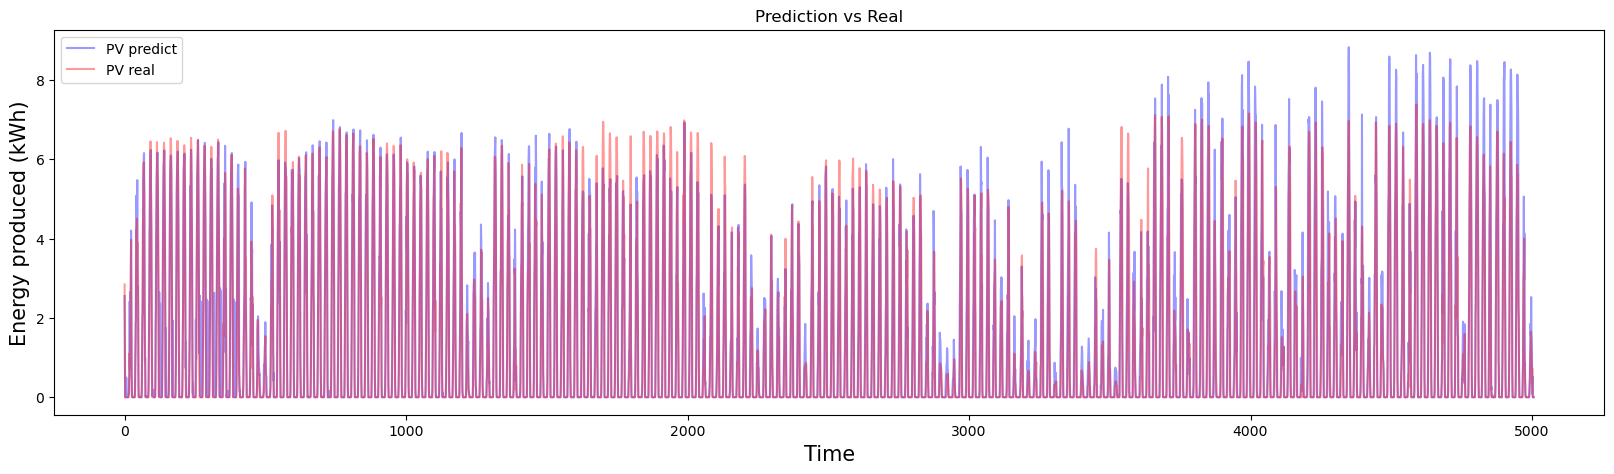

In [111]:
# Plot y_predict vs y_test

x = range(len(y_predict))
plt.figure(figsize=(20,5))
plt.xlabel('Time', size=15)
plt.ylabel('Energy produced (kWh)', size=15)
plt.plot(x, y_predict, alpha=0.4, color='blue', label='PV predict')
plt.plot(x, y_test, alpha=0.4, color='red',  label='PV real')
plt.title('Prediction vs Real')
plt.legend()
plt.show()

### We need to Zoom in!

If necessary, install the Plotly library ``!pip install plotly``.


In [141]:
import plotly.graph_objects as go  # Importamos la librería de plotly

init = list(range(len(y_predict)))
y_predict_plot = pd.DataFrame(data=y_predict, index=init, columns=['predict'])

# Reindex y_test so it starts from 0, ensuring y_predict and y_test share the same index for plotting
y_test_plot = pd.DataFrame(data=y_test.values, index=init, columns=['test'])


# We create figure
fig = go.Figure()
fig.add_trace(go.Scatter(x=init, y=y_predict_plot['predict'][init],
                    mode='lines',
                    name='PV prediction'))
fig.add_trace(go.Scatter(x=init, y=y_test_plot['test'][init],
                     mode='lines', name='PV real'))


# We edit figure
fig.update_layout(autosize=False,
                  width=1000,
                    height=500,
                    title='Prediction vs Real',
                   xaxis_title='Periods',
                   yaxis_title='Energy (kWh)')


fig.show()

### Most important features/attributes 

Which features carry the most weight in this example? 

* Not to be confused with correlation matrix, which is not the same thing. For more info: tree.feaure_importances https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html 

* This does not work with all ML regression models.



Feature ranking:
1. feature 5 (0.907707)radiation
2. feature 7 (0.047111)hour
3. feature 2 (0.015105)humidity
4. feature 0 (0.009184)pressure
5. feature 1 (0.008521)temperature
6. feature 6 (0.008496)month
7. feature 3 (0.003740)windspeed
8. feature 4 (0.000136)rain


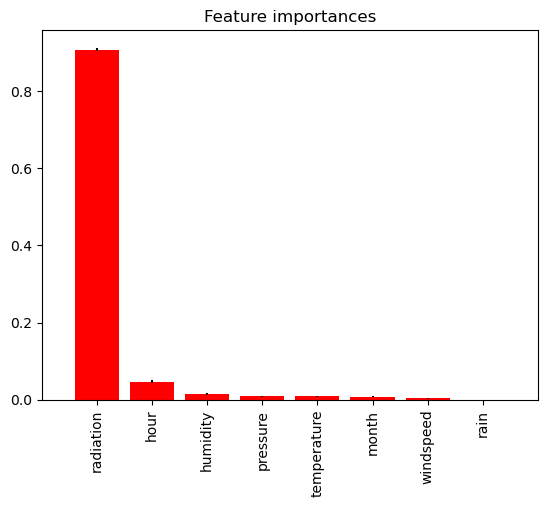

In [113]:

# We print the feature ranking
importances = gsearch.best_estimator_.feature_importances_
std = np.std([tree.feature_importances_ for tree in gsearch.best_estimator_.estimators_], axis=0)
indices = np.argsort(importances)[::-1]
feat = X.columns
feat_or=[]
print("Feature ranking:")
for f in range(X.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]])+feat[indices[f]])
    feat_or.append(feat[indices[f]])

# We plot the weight of the features that matter most for RandomForest()
plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices],
       color="r", yerr=std[indices], align="center")
plt.xticks(range(X.shape[1]), feat_or, rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()